![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/05/logo-upv-horizontal.png)
![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/06/logos-perte-chip-1024x119.png)

# Laboratory 3. Circuits and Compact Models

 ## 0.1 Import libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm

import logging
import sys
from functools import partial
from pprint import pprint

import gdsfactory as gf
import jax
import jax.example_libraries.optimizers as opt
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import sax
from gdsfactory.generic_tech import get_generic_pdk
from numpy.fft import fft2, fftfreq, fftshift, ifft2
from rich.logging import RichHandler
from scipy import constants
from sklearn.linear_model import LinearRegression
from tqdm.notebook import trange
from scipy.constants import c as c0

import gplugins.sax as gs
import gplugins.tidy3d as gt
from gplugins.common.config import PATH

logger = logging.getLogger()
logger.removeHandler(sys.stderr)
logging.basicConfig(level="WARNING", datefmt="[%X]", handlers=[RichHandler()])

/tmp/ipykernel_1003/616826865.py:17: DeprecationWarning: The 'gdsfactory.generic_tech' module is deprecated and will be removed in a future version. Please update your imports to use 'gdsfactory.gpdk' instead:
  from gdsfactory.gpdk import LAYER, LAYER_STACK, get_generic_pdk
Or for submodules:
  from gdsfactory.gpdk.layer_map import LAYER
  from gdsfactory.gpdk.layer_stack import LAYER_STACK
  from gdsfactory.generic_tech import get_generic_pdk


## 0.2 Compact Models for simulations

### 0.2.1. Waveguide compact model (Lab1. LO4)

We start from the waveguide's effective index second degree polynomial:

$$
n_\mathrm{eff}(\lambda)
= n_{1} + n_{2}\,(\lambda-\lambda_{0}) + n_{3}\,(\lambda-\lambda_{0})^{2}
$$

Or from the parameters derived from the polynomial coefficients: 
 
$$
n_\mathrm{eff}(\lambda_0) = n_1~ ;~ n_g(\lambda_0) = n_1 - n_2\,\lambda_0~;~ D = -\frac{2\,\lambda_0\,n_3}{c}\;\;[\mathrm{s}^2/\mathrm{m}]
$$

The transmmission through the waveguide should be modeled as: 

$$
H(\lambda)
= e^{-j\,\beta(\lambda)\,z}
= e^{-j\,\mathrm{Re}\{\beta(\lambda)\}\,z}\,
  e^{\mathrm{Im}\{\beta(\lambda)\}\,z}.
$$
With  
$$
\beta(\lambda)
= \frac{2\pi}{\lambda}\,\mathrm{Re}\{n_\mathrm{eff}(\lambda)\}.
$$

We are going to use [SAX](https://pypi.org/project/sax/), a scatter parameter circuit simulator, to implement simulations in the frequency (wavelength) domain. The following cell demonstrates how to define the most basic component transfer function: 

In [3]:
# The model should be a Python function that takes as input the relevant parameters
# (e.g., wavelength, effective index, length, loss) and returns a SAX SDict representing
# the waveguide's S-parameters.
# Parameters:
# wl: Wavelength to simulate (um)
# wl0: Reference wavelength - where you calculated the group index and dispersion (um))
# neff: Effective index at the reference wavelength (au)
# ng: Group index (au)
# length: Length of the waveguide in micrometers (um)
# loss: Propagation loss in dB/um (Experimental value)
# D: Dispersion parameter (s^2/m)
def waveguide(wl=1.55, wl0=1.55, neff=1.6072, ng=2.0, length=10.0, loss=0.0, D=0) -> sax.SDict:
    dwl = wl - wl0
    n1 = neff
    n2 = (n1-ng)/wl0
    n3 = -D*c0/(2*wl0)
    neff = n1 + n2*dwl + n3*dwl**2
    phase = 2 * jnp.pi * neff * length / wl
    transmission = 10 ** (-loss * length / 20) * jnp.exp(1j * phase)
    wg_dict = sax.reciprocal(
        {
            ("in0", "out0"): transmission,
        }
    )
    return wg_dict

### 0.2.2. Coupler compact model (Lab2 LO6)

We can start with the ideal coupler transfer function. You can then update your model with the parameters you found in your Laboratory 2. The model we are going to implement does not take into account if the coupler is an MMI or a Directional Coupler, it just use as parameters the coupling coefficient to calculate the output power at each port. 

$$
\begin{pmatrix}
E_{o1}\\
E_{o2}
\end{pmatrix}
=
\begin{pmatrix}
\sqrt{1-K} & -\mathrm{j}\sqrt{K}\\
-\mathrm{j}\sqrt{K} & \sqrt{1-K}
\end{pmatrix}
\begin{pmatrix}
E_{i1}\\
E_{i2}
\end{pmatrix}
$$

In [4]:
# Coupler Model
# We define again the Python function for the coupler compact model.
# Parameters:
# coupling: Coupling coefficient (between 0 and 1)
# You MUST update the model with the parameters you found in your Laboratory 2: 
# Excess loss, actual phase shift.
def coupler(coupling=0.5) -> sax.SDict:
    kappa = coupling**0.5
    tau = (1 - coupling) ** 0.5
    # The coupler is a reciprocal device, so we use sax.reciprocal to create the SDict
    # (reciprocal device means it behaves the same way in both directions)
    coupler_dict = sax.reciprocal(
        {
            ("in0", "out0"): tau,
            ("in0", "out1"): kappa * np.exp(-1j * np.pi / 2.0),
            ("in1", "out0"): kappa * np.exp(-1j * np.pi / 2.0),
            ("in1", "out1"): tau,
        }
    )
    return coupler_dict


## LO.1. Mach - Zehnder Interferometer

### 1.1. MZI Circuit Model

Using SAX library, we can now define the components, connections and models needed to build our circuit. Let's start with the MZI: 

<img src="mzi.png" alt="mzi circuit" width="600">

We will need two couplers and two waveguides: 


In [4]:
# MZI Circuit
# We will define instances, connections and ports for the MZI circuit using the SAX library.
# We will use the coupler and waveguide models defined above.
mzi, info = sax.circuit(
    netlist={
        # Define instances of couplers and waveguides
        "instances": {
            "coup_E": "coupler",
            "wvg_N": "waveguide",
            "wvg_S": "waveguide",
            "coup_W": "coupler",
        },
        # Define connections between the instances
        "connections": {
            "coup_E,out0": "wvg_S,in0",
            "wvg_S,out0": "coup_W,in0",
            "coup_E,out1": "wvg_N,in0",
            "wvg_N,out0": "coup_W,in1",
        },
        # Define the external ports of the MZI circuit
        "ports": {
            "in0": "coup_E,in0",
            "in1": "coup_E,in1",
            "out0": "coup_W,out0",
            "out1": "coup_W,out1",
        },
    },
    # Important! Provide here the models for the components used in the circuit
    # Here we use the coupler and waveguide functions defined above
    models={
        "coupler": coupler,
        "waveguide": waveguide,
    },
)


[19:54:45] WARNING  WARNING:jax._src.xla_bridge:An NVIDIA GPU may be present on this machine, but ]8;id=644566;file:///home/yhabela/cifoin-lab3/.venv/lib/python3.12/site-packages/jax/_src/xla_bridge.py\xla_bridge.py]8;;\:]8;id=135441;file:///home/yhabela/cifoin-lab3/.venv/lib/python3.12/site-packages/jax/_src/xla_bridge.py#864\864]8;;\
                    a CUDA-enabled jaxlib is not installed. Falling back to cpu.                                   

Using this circuit model, it is possible now to perform simulations to obtain the MZI response:

Text(0, 0.5, '|H|^2 [dB]')

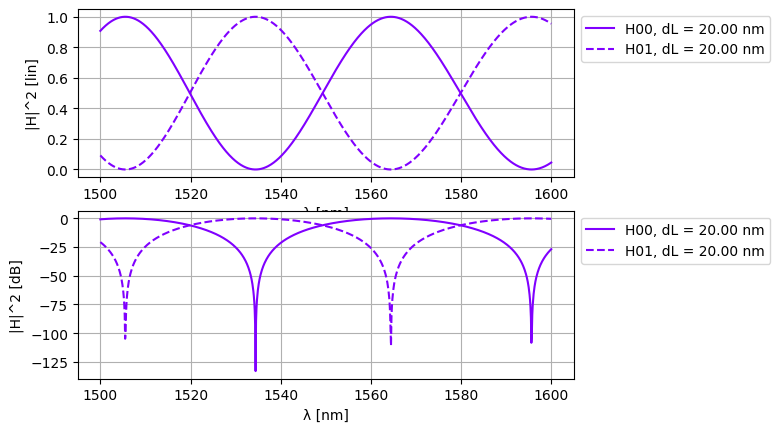

In [5]:
# Wavelengths to simulate
wl = jnp.linspace(1.50, 1.60, 1000)

# Length values to simulate. We have a base length and we will vary the length of one arm using delta_l_v
delta_l_v = np.array([20,]) 
l_base = 10.0

# Testbench
mzi_test = []

n_curves = np.shape(delta_l_v)[0]
color = cm.rainbow(np.linspace(0, 1, n_curves))

fig, ax = plt.subplots(2,1)
for i, delta_l in enumerate(delta_l_v):
    # Simulate MZI with given length difference
    # We can access the waveguide lengths by using the instance names defined in the circuit
    # First we instantiate the MZI with the desired lengths
    mzi_test = mzi(wl=wl, wvg_S={"length": l_base}, wvg_N={"length": l_base+delta_l})
    # Then we can extract the S-parameters using the port names defined in the circuit
    H00 = mzi_test["in0", "out0"]
    H01 = mzi_test["in0", "out1"]

    H00_dB = 20.0*jnp.log10(np.abs(H00) ** 2)
    H01_dB = 20.0*jnp.log10(np.abs(H01) ** 2)

    ax[0].plot(wl * 1e3, np.abs(H00)**2, linestyle="-", color=color[i], label=f"H00, dL = {delta_l:.2f} nm")
    ax[0].plot(wl * 1e3, np.abs(H01)**2, linestyle="--", color=color[i], label=f"H01, dL = {delta_l:.2f} nm")

    ax[1].plot(wl * 1e3, H00_dB, linestyle="-", color=color[i], label=f"H00, dL = {delta_l:.2f} nm")
    ax[1].plot(wl * 1e3, H01_dB, linestyle="--", color=color[i], label=f"H01, dL = {delta_l:.2f} nm")

for i in range(0,2):
    ax[i].grid(visible=True)
    ax[i].legend(fontsize=8)
    ax[i].set_xlabel("λ [nm]")
    ax[i].legend(loc='upper left', bbox_to_anchor=(1, 1))

ax[0].set_ylabel("|H|^2 [lin]")
ax[1].set_ylabel("|H|^2 [dB]")

The resulting interference pattern allows us to determine the **free spectral range** (FSR). By locating two adjacent notches in the transfer function, the difference between their wavelengths gives the FSR, which satisfies:

$$
\Delta\lambda_{\mathrm{FSR}}
= \frac{\lambda^{2}}{n_g(\lambda)\,\Delta L}
$$

You can use this code section with certain variations for LO1a,1b,2 and 3.

### 1.a – Perfectly balanced MZI


Text(0, 0.5, '|H|^2 [dB]')

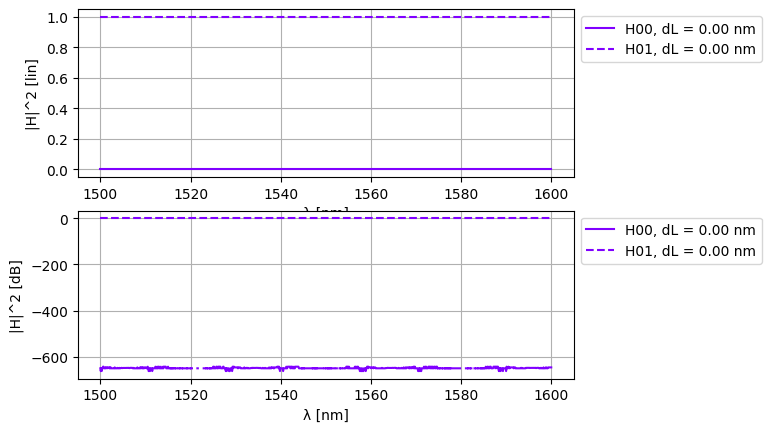

In [11]:
# Wavelengths to simulate
wl = jnp.linspace(1.50, 1.60, 1000)

# Length values to simulate. We have a base length and we will vary the length of one arm using delta_l_v
delta_l_v = np.array([0,]) 
l_base = 10

# Testbench
mzi_test = []

n_curves = np.shape(delta_l_v)[0]
color = cm.rainbow(np.linspace(0, 1, n_curves))

fig, ax = plt.subplots(2,1)
for i, delta_l in enumerate(delta_l_v):
    # Simulate MZI with given length difference
    # We can access the waveguide lengths by using the instance names defined in the circuit
    # First we instantiate the MZI with the desired lengths
    mzi_test = mzi(wl=wl, wvg_S={"length": l_base}, wvg_N={"length": l_base+delta_l})
    # Then we can extract the S-parameters using the port names defined in the circuit
    H00 = mzi_test["in0", "out0"]
    H01 = mzi_test["in0", "out1"]

    H00_dB = 20.0*jnp.log10(np.abs(H00) ** 2)
    H01_dB = 20.0*jnp.log10(np.abs(H01) ** 2)

    ax[0].plot(wl * 1e3, np.abs(H00)**2, linestyle="-", color=color[i], label=f"H00, dL = {delta_l:.2f} nm")
    ax[0].plot(wl * 1e3, np.abs(H01)**2, linestyle="--", color=color[i], label=f"H01, dL = {delta_l:.2f} nm")

    ax[1].plot(wl * 1e3, H00_dB, linestyle="-", color=color[i], label=f"H00, dL = {delta_l:.2f} nm")
    ax[1].plot(wl * 1e3, H01_dB, linestyle="--", color=color[i], label=f"H01, dL = {delta_l:.2f} nm")

for i in range(0,2):
    ax[i].grid(visible=True)
    ax[i].legend(fontsize=8)
    ax[i].set_xlabel("λ [nm]")
    ax[i].legend(loc='upper left', bbox_to_anchor=(1, 1))

ax[0].set_ylabel("|H|^2 [lin]")
ax[1].set_ylabel("|H|^2 [dB]")

### 1b – Unbalanced MZI



Text(0, 0.5, '|H|^2 [dB]')

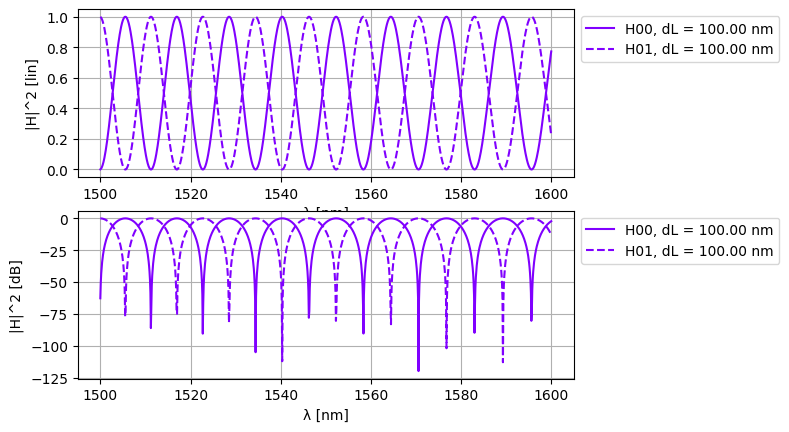

In [12]:
# Wavelengths to simulate
wl = jnp.linspace(1.50, 1.60, 1000)

# Length values to simulate. We have a base length and we will vary the length of one arm using delta_l_v
delta_l_v = np.array([100,]) 
l_base = 10

# Testbench
mzi_test = []

n_curves = np.shape(delta_l_v)[0]
color = cm.rainbow(np.linspace(0, 1, n_curves))

fig, ax = plt.subplots(2,1)
for i, delta_l in enumerate(delta_l_v):
    # Simulate MZI with given length difference
    # We can access the waveguide lengths by using the instance names defined in the circuit
    # First we instantiate the MZI with the desired lengths
    mzi_test = mzi(wl=wl, wvg_S={"length": l_base}, wvg_N={"length": l_base+delta_l})
    # Then we can extract the S-parameters using the port names defined in the circuit
    H00 = mzi_test["in0", "out0"]
    H01 = mzi_test["in0", "out1"]

    H00_dB = 20.0*jnp.log10(np.abs(H00) ** 2)
    H01_dB = 20.0*jnp.log10(np.abs(H01) ** 2)

    ax[0].plot(wl * 1e3, np.abs(H00)**2, linestyle="-", color=color[i], label=f"H00, dL = {delta_l:.2f} nm")
    ax[0].plot(wl * 1e3, np.abs(H01)**2, linestyle="--", color=color[i], label=f"H01, dL = {delta_l:.2f} nm")

    ax[1].plot(wl * 1e3, H00_dB, linestyle="-", color=color[i], label=f"H00, dL = {delta_l:.2f} nm")
    ax[1].plot(wl * 1e3, H01_dB, linestyle="--", color=color[i], label=f"H01, dL = {delta_l:.2f} nm")

for i in range(0,2):
    ax[i].grid(visible=True)
    ax[i].legend(fontsize=8)
    ax[i].set_xlabel("λ [nm]")
    ax[i].legend(loc='upper left', bbox_to_anchor=(1, 1))

ax[0].set_ylabel("|H|^2 [lin]")
ax[1].set_ylabel("|H|^2 [dB]")

## LO.2 – MZI Design



Delta L = 600.625 um


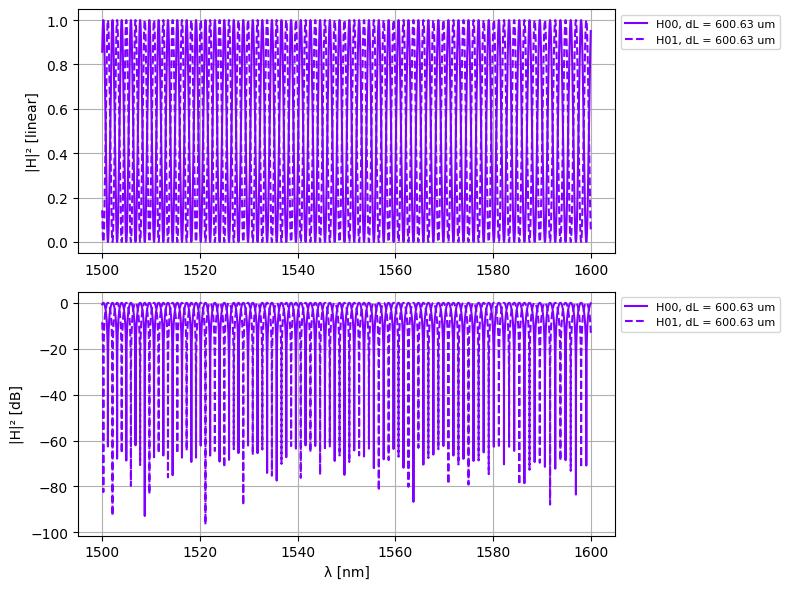

In [ ]:
# Wavelengths to simulate
# 1500-1600 nm with step 0.001 nm
wl_nm = np.arange(1500, 1600 + 0.001, 0.001)
wl = jnp.array(wl_nm * 1e-3)   # nm to um

# Design parameters
lambda0 = 1.55      # um
ng = 2.0
FSR = 0.002         # um = 2 nm

# Calculate length difference
delta_l = lambda0**2 / (ng * FSR)
print(f"Delta L = {delta_l:.3f} um")

delta_l_v = np.array([delta_l])
l_base = 10.0       # um

# Testbench
n_curves = np.shape(delta_l_v)[0]
color = cm.rainbow(np.linspace(0, 1, n_curves))

fig, ax = plt.subplots(2, 1, figsize=(8, 6))

for i, delta_l in enumerate(delta_l_v):

    mzi_test = mzi(
        wl=wl,
        coup_E={"coupling": 0.5},
        coup_W={"coupling": 0.5},
        wvg_S={"length": l_base},
        wvg_N={"length": l_base + delta_l},
    )

    H00 = mzi_test["in0", "out0"]
    H01 = mzi_test["in0", "out1"]

    H00_power = np.abs(H00) ** 2
    H01_power = np.abs(H01) ** 2

    H00_dB = 10.0 * jnp.log10(H00_power)
    H01_dB = 10.0 * jnp.log10(H01_power)

    ax[0].plot(wl_nm, H00_power, linestyle="-", color=color[i], label=f"H00, dL = {delta_l:.2f} um")
    ax[0].plot(wl_nm, H01_power, linestyle="--", color=color[i], label=f"H01, dL = {delta_l:.2f} um")

    ax[1].plot(wl_nm, H00_dB, linestyle="-", color=color[i], label=f"H00, dL = {delta_l:.2f} um")
    ax[1].plot(wl_nm, H01_dB, linestyle="--", color=color[i], label=f"H01, dL = {delta_l:.2f} um")

ax[0].set_ylabel("|H|² [linear]")
ax[1].set_ylabel("|H|² [dB]")
ax[1].set_xlabel("λ [nm]")

for i in range(2):
    ax[i].grid(True)
    ax[i].legend(fontsize=8, loc="upper left", bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

## LO.3 – Delay imbalance with loss


L_short = 1000.000 um
L_long  = 56960.084 um
Extra length = 55960.084 um
Loss = 0.000400 dB/um


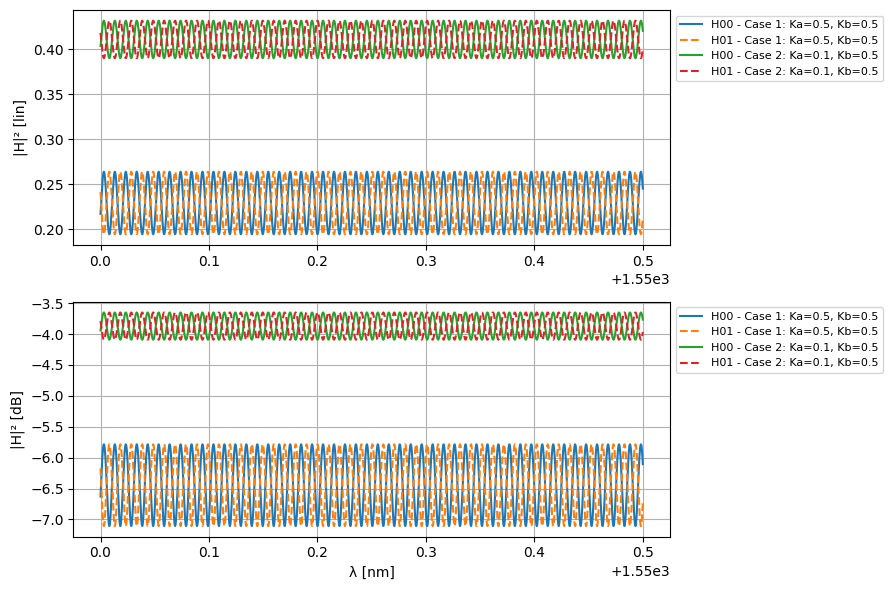

In [16]:
# Wavelength range
wl_nm = np.arange(1550, 1550.5 + 0.0000005, 0.0000005)
wl = jnp.array(wl_nm * 1e-3)   # nm -> um

# Silicon waveguide parameters
neff_si = 2.38
ng_si = 4.25
D_si = 0

# Loss conversion: 4 dB/cm = 4/10000 dB/um
loss_si = 4 / 10000

# Lengths
L_base = 1000
delta_L = 55960.0840224255

L_short = L_base
L_long = L_base + delta_L

print(f"L_short = {L_short:.3f} um")
print(f"L_long  = {L_long:.3f} um")
print(f"Extra length = {delta_L:.3f} um")
print(f"Loss = {loss_si:.6f} dB/um")

# Cases: (Ka, Kb)
cases = {
    "Case 1: Ka=0.5, Kb=0.5": (0.5, 0.5),
    "Case 2: Ka=0.1, Kb=0.5": (0.1, 0.5),
}

fig, ax = plt.subplots(2, 1, figsize=(9, 6))

for label, (Ka, Kb) in cases.items():

    mzi_test = mzi(
        wl=wl,
        coup_E={"coupling": Ka},
        coup_W={"coupling": Kb},
        wvg_S={
            "length": L_short,
            "neff": neff_si,
            "ng": ng_si,
            "D": D_si,
            "loss": loss_si,
        },
        wvg_N={
            "length": L_long,
            "neff": neff_si,
            "ng": ng_si,
            "D": D_si,
            "loss": loss_si,
        },
    )

    H00 = mzi_test["in0", "out0"]
    H01 = mzi_test["in0", "out1"]

    H00_power = np.abs(H00) ** 2
    H01_power = np.abs(H01) ** 2

    H00_dB = 10 * jnp.log10(H00_power)
    H01_dB = 10 * jnp.log10(H01_power)

    ax[0].plot(wl_nm, H00_power, label=f"H00 - {label}")
    ax[0].plot(wl_nm, H01_power, "--", label=f"H01 - {label}")

    ax[1].plot(wl_nm, H00_dB, label=f"H00 - {label}")
    ax[1].plot(wl_nm, H01_dB, "--", label=f"H01 - {label}")

ax[0].set_ylabel("|H|² [lin]")
ax[1].set_ylabel("|H|² [dB]")
ax[1].set_xlabel("λ [nm]")

for i in range(2):
    ax[i].grid(True)
    ax[i].legend(fontsize=8, loc="upper left", bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

In [17]:
def extinction_ratio_dB(power):
    Pmax = np.max(power)
    Pmin = np.min(power)
    ER = 10 * np.log10(Pmax / Pmin)
    return ER

for label, (Ka, Kb) in cases.items():

    mzi_test = mzi(
        wl=wl,
        coup_E={"coupling": Ka},
        coup_W={"coupling": Kb},
        wvg_S={
            "length": L_short,
            "neff": neff_si,
            "ng": ng_si,
            "D": D_si,
            "loss": loss_si,
        },
        wvg_N={
            "length": L_long,
            "neff": neff_si,
            "ng": ng_si,
            "D": D_si,
            "loss": loss_si,
        },
    )

    H00_power = np.abs(mzi_test["in0", "out0"]) ** 2
    H01_power = np.abs(mzi_test["in0", "out1"]) ** 2

    ER_H00 = extinction_ratio_dB(H00_power)
    ER_H01 = extinction_ratio_dB(H01_power)

    print(label)
    print(f"ER H00 = {ER_H00:.3f} dB")
    print(f"ER H01 = {ER_H01:.3f} dB")
    print()

Case 1: Ka=0.5, Kb=0.5
ER H00 = 1.323 dB
ER H01 = 1.323 dB

Case 2: Ka=0.1, Kb=0.5
ER H00 = 0.440 dB
ER H01 = 0.440 dB



Extra:


In [18]:
extra_loss_dB = loss_si * delta_L
a = 10 ** (-extra_loss_dB / 20)

Ka_match = 1 / (1 + a**2)

print(f"Extra loss = {extra_loss_dB:.3f} dB")
print(f"Ka to match amplitudes = {Ka_match:.4f}")

Extra loss = 22.384 dB
Ka to match amplitudes = 0.9943


## LO.4. Ring Resonators.

### 1.1. Ring Resonator Circuit Models

We can implement two different variations for the Ring Resonator. The simple ring that consist of a coupler connected with a waveguide (ring_ap), and the double bus ring that needs an extra coupler and the corresponding waveguides to make connections between them (ring_2bus): 

<img src="rings.png" alt="mzi circuit" width="600">


#### 1.1.1. Ring coupled to a single waveguide

We define one circuit per design variation. 

In [5]:
ring_ap, info = sax.circuit(
    netlist={
        "instances": {
            "coup": "coupler",
            "wvg_ring": "waveguide",
        },
        "connections": {
            "coup,out1": "wvg_ring,in0",
            "wvg_ring,out0": "coup,in1",
        },
        "ports": {
            "in0": "coup,in0",
            "out0": "coup,out0"
        },
    },
    models={
        "coupler": coupler,
        "waveguide": waveguide,
    },
)

[11:34:08] WARNING  WARNING:jax._src.xla_bridge:An NVIDIA GPU may be present on this machine, but ]8;id=222974;file:///home/yhabela/cifoin-lab3/.venv/lib/python3.12/site-packages/jax/_src/xla_bridge.py\xla_bridge.py]8;;\:]8;id=313560;file:///home/yhabela/cifoin-lab3/.venv/lib/python3.12/site-packages/jax/_src/xla_bridge.py#864\864]8;;\
                    a CUDA-enabled jaxlib is not installed. Falling back to cpu.                                   

Then we can test the circuit to check the functionality

Text(0, 0.5, '|H|^2 [dB]')

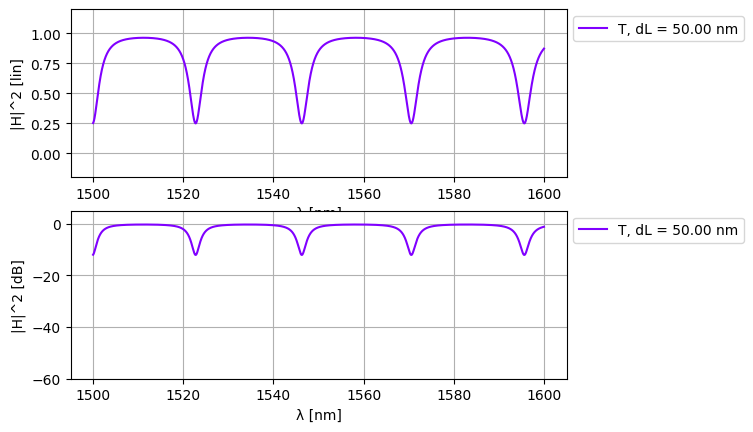

In [6]:
# Wavelengths to simulate
wl = jnp.linspace(1.50, 1.60, 10000)

# Length value to simulate. This is the length of the ring waveguide
delta_l_v = np.array([50,]) 

# Coupling coefficient of the input/output coupler
coupling = 0.5

n_curves = np.shape(delta_l_v)[0]
color = cm.rainbow(np.linspace(0, 1, n_curves))

fig, ax = plt.subplots(2,1)
for i, delta_l in enumerate(delta_l_v):
    # Here we instantiate the ring resonator with the desired ring length
    # Update this line if you desire to simulate different losses or coupling coefficients
    ring_ap_test = ring_ap(wl=wl, wvg_ring={"length": delta_l, "loss": 0.02}, coup={"coupling": coupling})
    T = ring_ap_test["in0", "out0"]

    T_dB = 20.0*jnp.log10(np.abs(T) ** 2)

    ax[0].plot(wl * 1e3, np.abs(T)**2, linestyle="-", color=color[i], label=f"T, dL = {delta_l:.2f} nm")

    ax[1].plot(wl * 1e3, T_dB, linestyle="-", color=color[i], label=f"T, dL = {delta_l:.2f} nm")

ax[0].set_ylim([-0.2,1.2])
for i in range(0,2):
    ax[i].grid(visible=True)
    ax[i].legend(fontsize=8)
    ax[i].set_xlabel("λ [nm]")
    ax[i].legend(loc='upper left', bbox_to_anchor=(1, 1))
ax[1].set_ylim([-60,5])

ax[0].set_ylabel("|H|^2 [lin]")
ax[1].set_ylabel("|H|^2 [dB]")

#### 1.1.2. Ring coupled to two waveguides

For this design variation, the ring perimeter is divided into two straight sections that connect both couplers

In [9]:
ring_2bus, info = sax.circuit(
    netlist={
        "instances": {
            "wvg_S_in": "waveguide",
            "wvg_S_out": "waveguide",
            "coup_S": "coupler",
            "wvg_ring_E": "waveguide",
            "wvg_ring_W": "waveguide",
            "coup_N": "coupler",
            "wvg_N_in": "waveguide",
            "wvg_N_out": "waveguide",
        },
        "connections": {
            "wvg_S_in,out0": "coup_S,in0",
            "coup_S,out0": "wvg_S_out,in0",
            "coup_S,out1": "wvg_ring_E,in0",
            "wvg_ring_E,out0": "coup_N,in1",
            "coup_N,out1": "wvg_ring_W,in0",
            "wvg_ring_W,out0": "coup_S,in1",
            "wvg_N_in,out0": "coup_N,in0",
            "coup_N,out0": "wvg_N_out,in0",
        },
        "ports": {
            "in0": "wvg_S_in,in0",
            "out0": "wvg_S_out,out0",
            "in1": "wvg_N_in,in0",
            "out1": "wvg_N_out,out0",
        },
    },
    models= {
        "coupler": coupler,
        "waveguide": waveguide,
    },
)

Test the circuit to check the functionality

Text(0, 0.5, '|H|^2 [dB]')

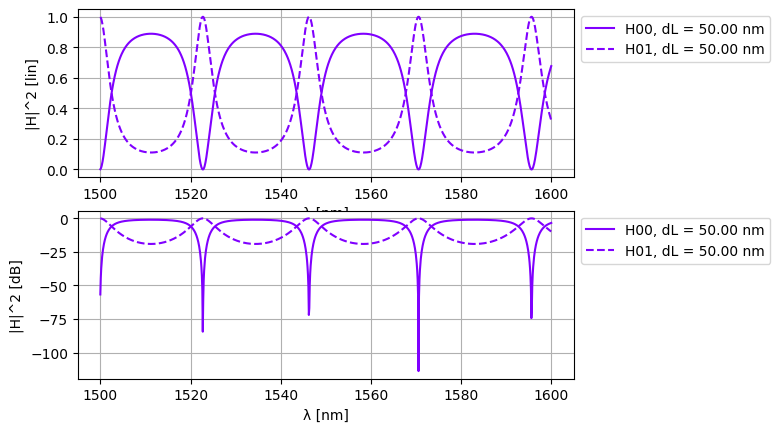

In [10]:
wl = jnp.linspace(1.50, 1.60, 1000)

delta_l_v = np.array([50,]) 

n_curves = np.shape(delta_l_v)[0]
color = cm.rainbow(np.linspace(0, 1, n_curves))

fig, ax = plt.subplots(2,1)
for i, delta_l in enumerate(delta_l_v):
    # ring_2bus_test = ring_2bus(wl=wl, wvg_ring_E={"length": 0.5*delta_l}, wvg_ring_W={"length": 0.5*delta_l, "loss": 2.0}, coup_N={"coupling": 0.0})
    ring_2bus_test = ring_2bus(wl=wl, wvg_ring_E={"length": 0.5*delta_l}, wvg_ring_W={"length": 0.5*delta_l})
    H00 = ring_2bus_test["in0", "out0"]
    H01 = ring_2bus_test["in0", "out1"]

    H00_dB = 20.0*jnp.log10(np.abs(H00) ** 2)
    H01_dB = 20.0*jnp.log10(np.abs(H01) ** 2)

    ax[0].plot(wl * 1e3, np.abs(H00)**2, linestyle="-", color=color[i], label=f"H00, dL = {delta_l:.2f} nm")
    ax[0].plot(wl * 1e3, np.abs(H01)**2, linestyle="--", color=color[i], label=f"H01, dL = {delta_l:.2f} nm")

    ax[1].plot(wl * 1e3, H00_dB, linestyle="-", color=color[i], label=f"H00, dL = {delta_l:.2f} nm")
    ax[1].plot(wl * 1e3, H01_dB, linestyle="--", color=color[i], label=f"H01, dL = {delta_l:.2f} nm")

for i in range(0,2):
    ax[i].grid(visible=True)
    ax[i].legend(fontsize=8)
    ax[i].set_xlabel("λ [nm]")
    ax[i].legend(loc='upper left', bbox_to_anchor=(1, 1))

ax[0].set_ylabel("|H|^2 [lin]")
ax[1].set_ylabel("|H|^2 [dB]")


The resulting interference pattern again exhibits a periodic behavior. We define again the **free spectral range** (FSR), which should satisfy in this case the relationship:

$$
\Delta\lambda_{\mathrm{FSR}}
= \frac{\lambda^{2}}{n_g(\lambda)\,L_r}
$$

Where $L_r$ is the ring perimeter. Note that in our circuit model, we neglect the length of the coupler, so the perimeter is defined by the length of the waveguide sections.

#### **HINT**

You can perform parametric variations using the codes provided by us, for instance, check this casi in which we performed a loss sweep. 

Text(0, 0.5, '|H|^2 [dB]')

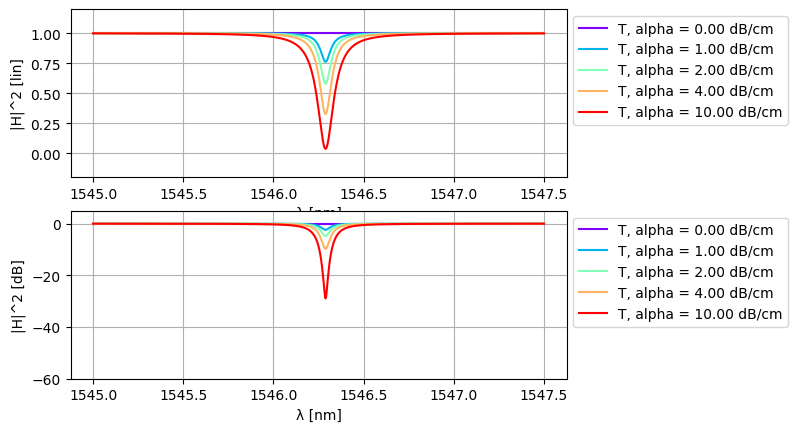

In [11]:
# We change the wavelength range to "zoom in" into a resonance
wl = jnp.linspace(1.545, 1.5475, 1000)

# Now we perform a loss sweep
loss_dBum = 1e-4*np.array([0,1,2,4,10])

n_curves = np.shape(loss_dBum)[0]
color = cm.rainbow(np.linspace(0, 1, n_curves))

ring_perimeter = 75.0
coupling = 0.025

fig, ax = plt.subplots(2,1)
#Update the variable you enumarate below
for i, loss in enumerate(loss_dBum):
    # Link the variable you want to sweep in the line below
    ring_ap_test = ring_ap(wl=wl, wvg_ring={"length": ring_perimeter, "loss": loss}, coup={"coupling": coupling})
    T = ring_ap_test["in0", "out0"]

    T_dB = 20.0*jnp.log10(np.abs(T) ** 2)

    ax[0].plot(wl * 1e3, np.abs(T)**2, linestyle="-", color=color[i], label=f"T, alpha = {1e4*loss:.2f} dB/cm")

    ax[1].plot(wl * 1e3, T_dB, linestyle="-", color=color[i], label=f"T, alpha = {1e4*loss:.2f} dB/cm")

ax[0].set_ylim([-0.2,1.2])
for i in range(0,2):
    ax[i].grid(visible=True)
    ax[i].legend(fontsize=8)
    ax[i].set_xlabel("λ [nm]")
    ax[i].legend(loc='upper left', bbox_to_anchor=(1, 1))
ax[1].set_ylim([-60,5])

ax[0].set_ylabel("|H|^2 [lin]")
ax[1].set_ylabel("|H|^2 [dB]")

Now use this code section to obtain the results of LOs4, 5, and 6.

#### **Learning outcome #4 – Ring Resonator**
Single ring resonator – most simple case Constant coupler K (no wavelength variation)


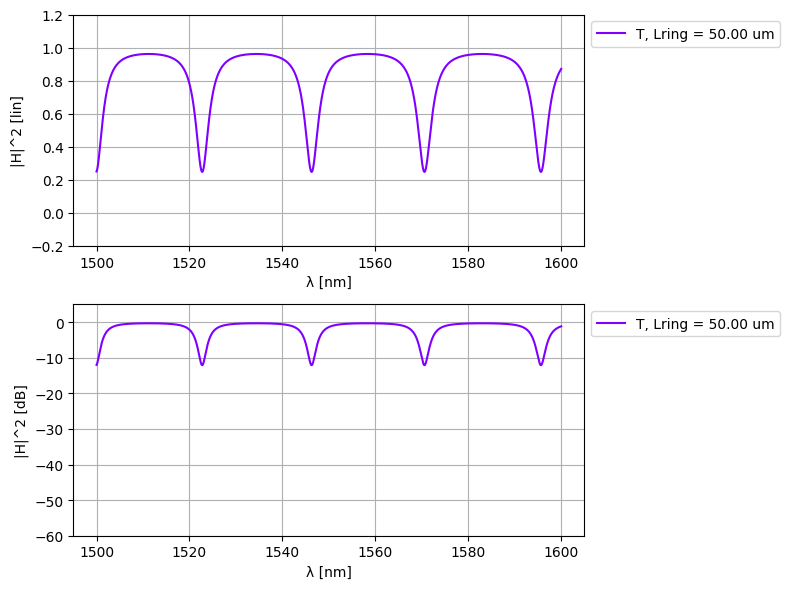

Ring perimeter = 50.00 um
FSR = 0.024025 um
FSR = 24.025 nm


In [14]:
# Wavelengths to simulate
wl = jnp.linspace(1.50, 1.60, 10000)

# Ring perimeter
delta_l_v = np.array([50,])   # um

# Coupling coefficient
coupling = 0.5

n_curves = np.shape(delta_l_v)[0]
color = cm.rainbow(np.linspace(0, 1, n_curves))

fig, ax = plt.subplots(2, 1, figsize=(8, 6))

for i, delta_l in enumerate(delta_l_v):

    # Single ring resonator simulation
    ring_ap_test = ring_ap(
        wl=wl,
        wvg_ring={
            "length": delta_l,
            "loss": 0.02,
        },
        coup={
            "coupling": coupling,
        },
    )

    # Transfer function
    T = ring_ap_test["in0", "out0"]

    # Linear and logarithmic units
    T_lin = np.abs(T) ** 2
    T_dB = 20.0 * jnp.log10(np.abs(T) ** 2)

    ax[0].plot(
        wl * 1e3,
        T_lin,
        linestyle="-",
        color=color[i],
        label=f"T, Lring = {delta_l:.2f} um",
    )

    ax[1].plot(
        wl * 1e3,
        T_dB,
        linestyle="-",
        color=color[i],
        label=f"T, Lring = {delta_l:.2f} um",
    )

ax[0].set_ylim([-0.2, 1.2])
ax[1].set_ylim([-60, 5])

for i in range(2):
    ax[i].grid(visible=True)
    ax[i].legend(fontsize=8)
    ax[i].set_xlabel("λ [nm]")
    ax[i].legend(loc="upper left", bbox_to_anchor=(1, 1))

ax[0].set_ylabel("|H|^2 [lin]")
ax[1].set_ylabel("|H|^2 [dB]")

plt.tight_layout()
plt.show()

# FSR calculation

lambda0 = 1.55   # um
ng = 2.0
Lring = 50.0     # um

FSR_um = lambda0**2 / (ng * Lring)
FSR_nm = FSR_um * 1000

print(f"Ring perimeter = {Lring:.2f} um")
print(f"FSR = {FSR_um:.6f} um")
print(f"FSR = {FSR_nm:.3f} nm")

#### **Learning outcome #5 – Ring resonator design**
Design the perimeter for a FSR = 15 nm. 


lambda0 = 1.550 um
ng = 2.00
FSR = 15.000 nm = 0.015000 um
L_ring = 80.083 um
Designed ring perimeter = 80.083 um
Target FSR = 15.000 nm


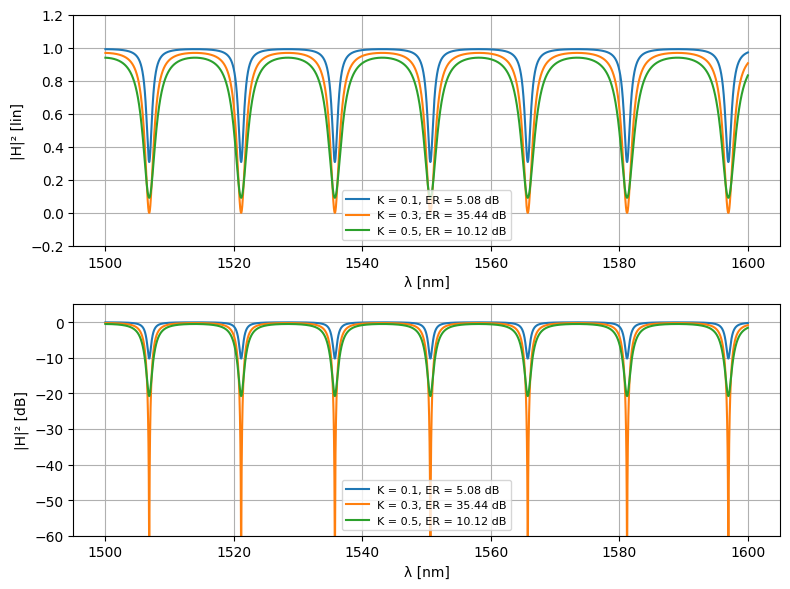

In [16]:
lambda0 = 1.55      # um, central wavelength = 1550 nm
ng = 2.0            # group index from the waveguide model
FSR_nm = 15         # nm

# Convert FSR from nm to um
FSR_um = FSR_nm * 1e-3

# Calculate ring perimeter
L_ring = lambda0**2 / (ng * FSR_um)

print(f"lambda0 = {lambda0:.3f} um")
print(f"ng = {ng:.2f}")
print(f"FSR = {FSR_nm:.3f} nm = {FSR_um:.6f} um")
print(f"L_ring = {L_ring:.3f} um")

# Wavelengths to simulate
wl = jnp.linspace(1.50, 1.60, 10000)

# Design parameters
lambda0 = 1.55      # um
ng = 2.0
FSR_target = 0.015  # um = 15 nm

# Designed ring perimeter
L_ring = lambda0**2 / (ng * FSR_target)

print(f"Designed ring perimeter = {L_ring:.3f} um")
print(f"Target FSR = {FSR_target*1000:.3f} nm")

# Coupling coefficients to compare
couplings = [0.1, 0.3, 0.5]

# Ring loss
loss_ring = 0.02   # dB/um

fig, ax = plt.subplots(2, 1, figsize=(8, 6))

for coupling in couplings:

    ring_ap_test = ring_ap(
        wl=wl,
        wvg_ring={
            "length": L_ring,
            "loss": loss_ring,
        },
        coup={
            "coupling": coupling,
        },
    )

    T = ring_ap_test["in0", "out0"]

    T_lin = np.abs(T) ** 2
    T_dB = 20.0 * jnp.log10(np.abs(T) ** 2)

    ER = 10 * np.log10(np.max(T_lin) / np.min(T_lin))

    ax[0].plot(
        wl * 1e3,
        T_lin,
        label=f"K = {coupling}, ER = {ER:.2f} dB"
    )

    ax[1].plot(
        wl * 1e3,
        T_dB,
        label=f"K = {coupling}, ER = {ER:.2f} dB"
    )

ax[0].set_ylim([-0.2, 1.2])
ax[1].set_ylim([-60, 5])

for i in range(2):
    ax[i].grid(visible=True)
    ax[i].legend(fontsize=8)
    ax[i].set_xlabel("λ [nm]")

ax[0].set_ylabel("|H|² [lin]")
ax[1].set_ylabel("|H|² [dB]")

plt.tight_layout()
plt.show()


critical coupling:

In [ ]:
# Critical coupling calculation

round_trip_loss_dB = loss_ring * L_ring

# Field attenuation after one round trip
a = 10 ** (-round_trip_loss_dB / 20)

# Critical coupling condition: tau = a
# Since tau^2 = 1 - K, then Kcrit = 1 - a^2
Kcrit = 1 - a**2

print(f"Round-trip loss = {round_trip_loss_dB:.3f} dB")
print(f"Round-trip field attenuation a = {a:.4f}")
print(f"Critical coupling coefficient Kcrit = {Kcrit:.4f}")

#### **Learning outcome #6a – Effect of K**
Change K value between 0.1 and 0.9 in steps of 0.1


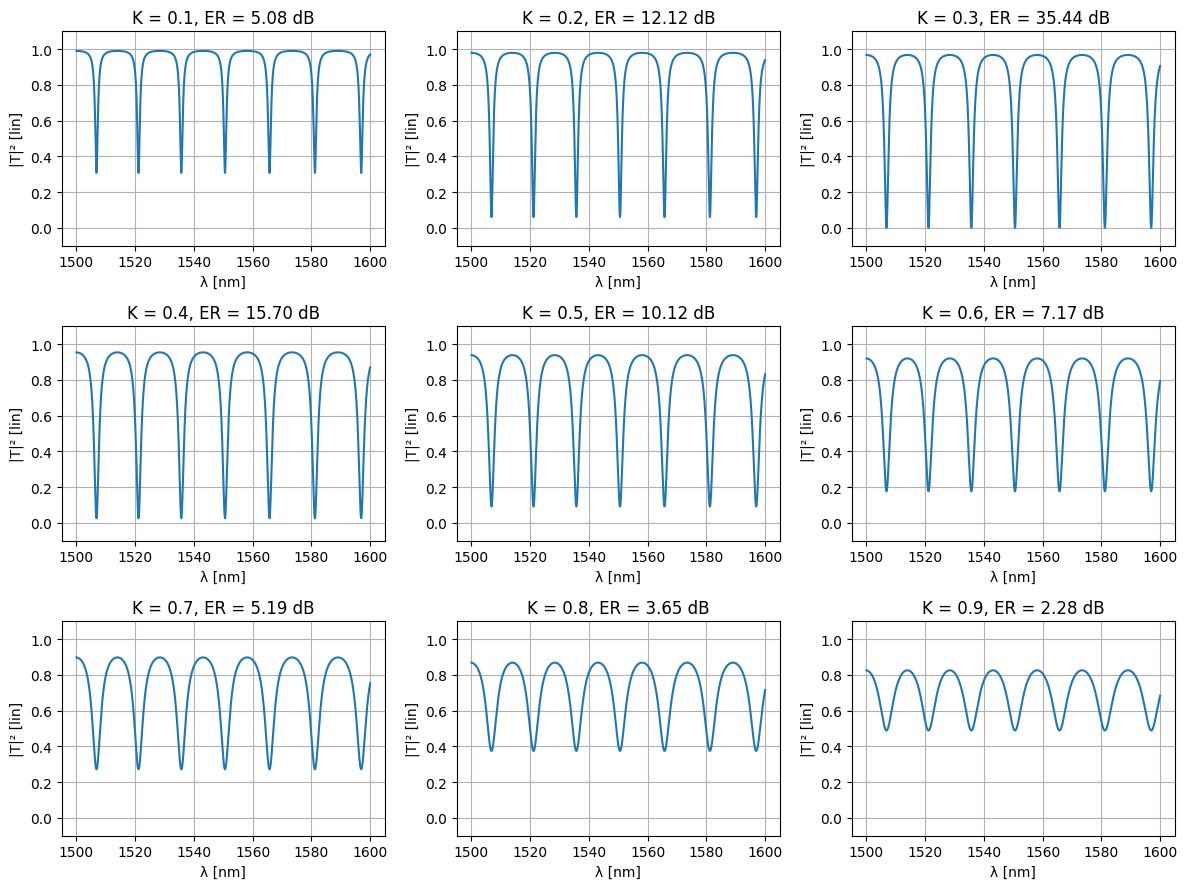

L_ring = 80.083 um
Extinction Ratio for each K:
K = 0.1 -> ER = 5.08 dB
K = 0.2 -> ER = 12.12 dB
K = 0.3 -> ER = 35.44 dB
K = 0.4 -> ER = 15.70 dB
K = 0.5 -> ER = 10.12 dB
K = 0.6 -> ER = 7.17 dB
K = 0.7 -> ER = 5.19 dB
K = 0.8 -> ER = 3.65 dB
K = 0.9 -> ER = 2.28 dB


In [18]:
L_ring = 80.083  # um
loss_ring = 0.02 # dB/um


# Wavelength range
wl = jnp.linspace(1.50, 1.60, 10000)

# Ring designed in outcome #5
lambda0 = 1.55      # um
ng = 2.0
FSR_target = 0.015  # um = 15 nm

L_ring = lambda0**2 / (ng * FSR_target)

# Ring loss
loss_ring = 0.02   # dB/um

# K sweep from 0.1 to 0.9
K_values = np.arange(0.1, 1.0, 0.1)

fig, ax = plt.subplots(3, 3, figsize=(12, 9))
ax = ax.flatten()

ER_values = []

for i, K in enumerate(K_values):

    ring_ap_test = ring_ap(
        wl=wl,
        wvg_ring={
            "length": L_ring,
            "loss": loss_ring,
        },
        coup={
            "coupling": K,
        },
    )

    T = ring_ap_test["in0", "out0"]

    T_lin = np.abs(T) ** 2

    ER = 10 * np.log10(np.max(T_lin) / np.min(T_lin))
    ER_values.append(ER)

    ax[i].plot(wl * 1e3, T_lin)
    ax[i].set_title(f"K = {K:.1f}, ER = {ER:.2f} dB")
    ax[i].set_xlabel("λ [nm]")
    ax[i].set_ylabel("|T|² [lin]")
    ax[i].grid(True)
    ax[i].set_ylim([-0.1, 1.1])

plt.tight_layout()
plt.show()

# Print numerical results
print(f"L_ring = {L_ring:.3f} um")
print("Extinction Ratio for each K:")

for K, ER in zip(K_values, ER_values):
    print(f"K = {K:.1f} -> ER = {ER:.2f} dB")

calcular el K crítico

In [19]:
# Critical coupling calculation

round_trip_loss_dB = loss_ring * L_ring

# Field attenuation after one round trip
a = 10 ** (-round_trip_loss_dB / 20)

# Critical coupling condition: tau = a
# tau^2 = 1 - K
Kcrit = 1 - a**2

print(f"Round-trip loss = {round_trip_loss_dB:.3f} dB")
print(f"Round-trip field attenuation a = {a:.4f}")
print(f"Critical coupling coefficient Kcrit = {Kcrit:.4f}")

Round-trip loss = 1.602 dB
Round-trip field attenuation a = 0.8316
Critical coupling coefficient Kcrit = 0.3084


#### **Learning outcome #6b – Effect of loss**
Change losses value between 0 and 8 dB/cm in steps of 1


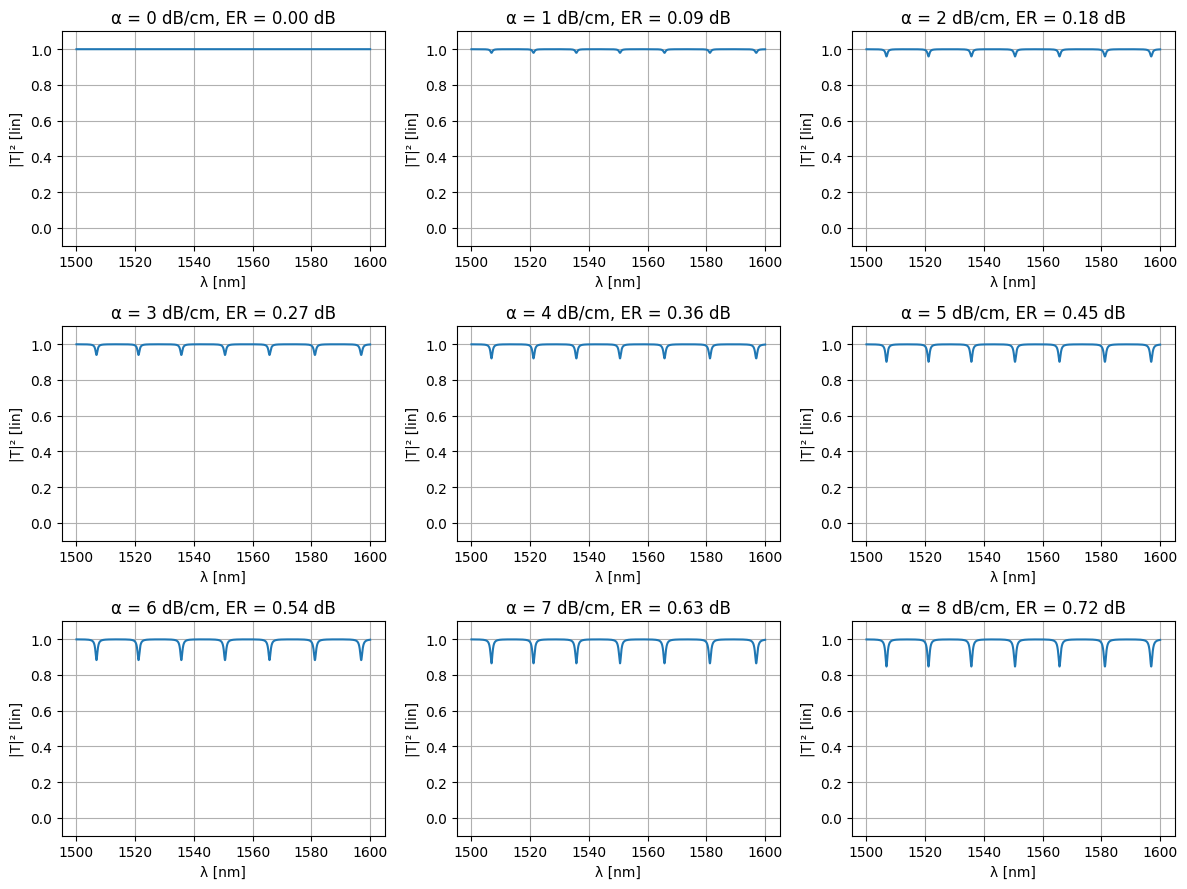

L_ring = 80.083 um
Fixed coupling K = 0.30
Extinction Ratio for each loss:
alpha = 0 dB/cm -> ER = 0.00 dB
alpha = 1 dB/cm -> ER = 0.09 dB
alpha = 2 dB/cm -> ER = 0.18 dB
alpha = 3 dB/cm -> ER = 0.27 dB
alpha = 4 dB/cm -> ER = 0.36 dB
alpha = 5 dB/cm -> ER = 0.45 dB
alpha = 6 dB/cm -> ER = 0.54 dB
alpha = 7 dB/cm -> ER = 0.63 dB
alpha = 8 dB/cm -> ER = 0.72 dB


In [20]:
# Learning outcome #6b - Effect of loss

# Wavelength range
wl = jnp.linspace(1.50, 1.60, 10000)

# Ring designed in outcome #5
lambda0 = 1.55      # um
ng = 2.0
FSR_target = 0.015  # um = 15 nm

L_ring = lambda0**2 / (ng * FSR_target)

# Fixed coupling coefficient
# We use K = 0.3 because it was closest to critical coupling in 6a
coupling = 0.3

# Loss sweep from 0 to 8 dB/cm
alpha_dBcm_values = np.arange(0, 9, 1)

fig, ax = plt.subplots(3, 3, figsize=(12, 9))
ax = ax.flatten()

ER_values = []

for i, alpha_dBcm in enumerate(alpha_dBcm_values):

    # Convert dB/cm to dB/um
    loss_dBum = alpha_dBcm / 10000

    ring_ap_test = ring_ap(
        wl=wl,
        wvg_ring={
            "length": L_ring,
            "loss": loss_dBum,
        },
        coup={
            "coupling": coupling,
        },
    )

    T = ring_ap_test["in0", "out0"]

    T_lin = np.abs(T) ** 2

    ER = 10 * np.log10(np.max(T_lin) / np.min(T_lin))
    ER_values.append(ER)

    ax[i].plot(wl * 1e3, T_lin)
    ax[i].set_title(f"α = {alpha_dBcm:.0f} dB/cm, ER = {ER:.2f} dB")
    ax[i].set_xlabel("λ [nm]")
    ax[i].set_ylabel("|T|² [lin]")
    ax[i].grid(True)
    ax[i].set_ylim([-0.1, 1.1])

plt.tight_layout()
plt.show()

# Print numerical results
print(f"L_ring = {L_ring:.3f} um")
print(f"Fixed coupling K = {coupling:.2f}")
print("Extinction Ratio for each loss:")

for alpha_dBcm, ER in zip(alpha_dBcm_values, ER_values):
    print(f"alpha = {alpha_dBcm:.0f} dB/cm -> ER = {ER:.2f} dB")

pérdida está más cerca del acoplo crítico

In [22]:
# Check critical coupling condition for each loss

print("Critical coupling comparison:")

for alpha_dBcm in alpha_dBcm_values:

    loss_dBum = alpha_dBcm / 10000

    round_trip_loss_dB = loss_dBum * L_ring

    a = 10 ** (-round_trip_loss_dB / 20)

    Kcrit = 1 - a**2

    print(
        f"alpha = {alpha_dBcm:.0f} dB/cm -> "
        f"round-trip loss = {round_trip_loss_dB:.4f} dB, "
        f"Kcrit = {Kcrit:.4f}"
    )

Critical coupling comparison:
alpha = 0 dB/cm -> round-trip loss = 0.0000 dB, Kcrit = 0.0000
alpha = 1 dB/cm -> round-trip loss = 0.0080 dB, Kcrit = 0.0018
alpha = 2 dB/cm -> round-trip loss = 0.0160 dB, Kcrit = 0.0037
alpha = 3 dB/cm -> round-trip loss = 0.0240 dB, Kcrit = 0.0055
alpha = 4 dB/cm -> round-trip loss = 0.0320 dB, Kcrit = 0.0073
alpha = 5 dB/cm -> round-trip loss = 0.0400 dB, Kcrit = 0.0092
alpha = 6 dB/cm -> round-trip loss = 0.0481 dB, Kcrit = 0.0110
alpha = 7 dB/cm -> round-trip loss = 0.0561 dB, Kcrit = 0.0128
alpha = 8 dB/cm -> round-trip loss = 0.0641 dB, Kcrit = 0.0146
